# Employee Churn in Healthcare

---

## Business Scenario
A healthcare organization wants to optimaize its employee managent strategies to enhance productivity and employee satisfaction. The organization has collected extensive data on its employees across various departments and seeks to leverage this data to make informed decisions. 

---

## Business Problem
The organization faces high attrition rates and varying levels of employee satisfaction across departments. There is a need to identify the factors contributing to these issues and develop strategies to improve employee retention and job satisfaction.

In [70]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns


In [71]:
# Global chart settings — applied to every plot in this notebook
PALETTE = {'No': '#2A6EBB', 'Yes': '#C0392B'}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'sans-serif',
})

In [72]:
# Load the data
df = pd.read_csv('watson_healthcare_modified2.csv')

In [73]:
# ── Data Quality Check ──────────────────────────────────────────────────────

print("DATASET SHAPE")
print()
print(f"  Rows: {df.shape[0]:,}   |   Columns: {df.shape[1]}")

# --- Null values ---
print()
print("MISSING VALUES")
print()
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
missing = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
missing = missing[missing['Null Count'] > 0]
if missing.empty:
    print("  No missing values found.")
else:
    print(missing)

# --- Duplicate rows ---
print()
print("DUPLICATE ROWS")
print()
dupes = df.duplicated().sum()
print(f"  Duplicate rows: {dupes}")

# --- Constant columns
print()
print("CONSTANT COLUMNS  (single unique value)")
print()
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
if constant_cols:
    for col in constant_cols:
        print(f"  {col}: always = {df[col].iloc[0]!r}")
else:
    print("  None found.")

# --- Data types summary ---
print()
print("DATA TYPES SUMMARY")
print()
dtype_summary = df.dtypes.value_counts().reset_index()
dtype_summary.columns = ['dtype', 'column_count']
print(dtype_summary.to_string(index=False))

DATASET SHAPE

  Rows: 1,676   |   Columns: 35

MISSING VALUES

  No missing values found.

DUPLICATE ROWS

  Duplicate rows: 0

CONSTANT COLUMNS  (single unique value)

  EmployeeCount: always = np.int64(1)
  Over18: always = 'Y'
  StandardHours: always = np.int64(80)

DATA TYPES SUMMARY

 dtype  column_count
 int64            26
object             9


In [74]:
# Drop constant columns — zero variance means zero analytical value
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped: {cols_to_drop}")
print(f"Dataset now: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped: ['EmployeeCount', 'Over18', 'StandardHours']
Dataset now: 1,676 rows × 32 columns


In [75]:
print(df.head())

print(df.info())
print(df.describe())

   EmployeeID  Age Attrition     BusinessTravel  DailyRate  Department  \
0     1313919   41        No      Travel_Rarely       1102  Cardiology   
1     1200302   49        No  Travel_Frequently        279   Maternity   
2     1060315   37       Yes      Travel_Rarely       1373   Maternity   
3     1272912   33        No  Travel_Frequently       1392   Maternity   
4     1414939   27        No      Travel_Rarely        591   Maternity   

   DistanceFromHome  Education EducationField  EnvironmentSatisfaction  ...  \
0                 1          2  Life Sciences                        2  ...   
1                 8          1  Life Sciences                        3  ...   
2                 2          2          Other                        4  ...   
3                 3          4  Life Sciences                        4  ...   
4                 2          1        Medical                        1  ...   

  PerformanceRating  RelationshipSatisfaction  Shift  TotalWorkingYears  \
0    

---

## Phase 1 — Understanding the basics

- Before understanding why employees leave.
- We need to understand how many leave and where. 
- This is the foundation for deeper analysis.

**Questions:**
1. What is the overall attrition rate (KPI)?
2. How does attrition differ across departments?
3. Age distribution of those who stayed vs left & Which age groups have the highest attrition?
4. Does attrition vary by gender or education level?

Status  Count % of Workforce
    No   1477         88.13%
   Yes    199         11.87%

Overall Attrition Rate: 11.87%


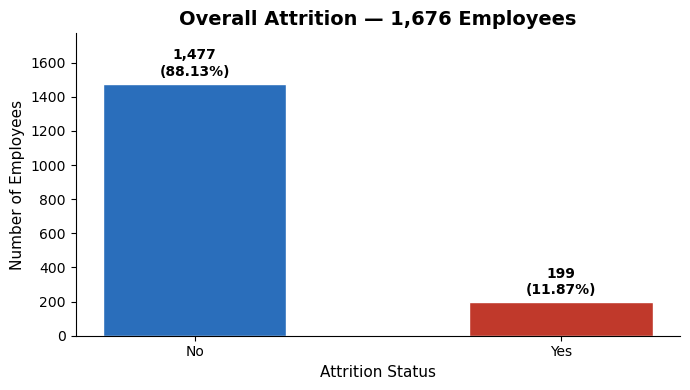

In [76]:
# Q1 — What is the overall attrition rate?

# Table
attrition_table = df['Attrition'].value_counts().reset_index()
attrition_table.columns = ['Status', 'Count']
attrition_table['% of Workforce'] = (attrition_table['Count'] / len(df) * 100).map('{:.2f}%'.format)
print(attrition_table.to_string(index=False))
print(f"\nOverall Attrition Rate: {(df['Attrition'] == 'Yes').mean() * 100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['Attrition'].value_counts()
bars = ax.bar(
    counts.index,
    counts.values,
    color=[PALETTE[k] for k in counts.index],
    width=0.5,
    edgecolor='white'
)
# Data labels on top of bars
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.max() * 0.02,
        f"{val:,}\n({pct:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title('Overall Attrition — 1,676 Employees')
ax.set_xlabel('Attrition Status')
ax.set_ylabel('Number of Employees')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Finding:** Nearly 1 in 8 employees left — an 11.87% attrition rate across 1,676 people. The organization lost 199 employees in this period. Recruiting, onboarding, and temporary coverage costs compound quickly at that volume, making this a financial problem, not just an HR metric.

Department  Total  Left  Stayed Attrition Rate
Cardiology  531.0  74.0   457.0          13.9%
 Maternity  796.0  98.0   698.0          12.3%
 Neurology  349.0  27.0   322.0           7.7%


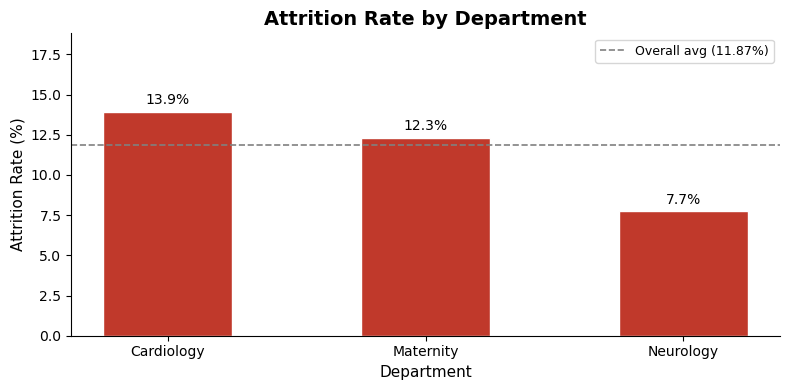

In [77]:
# Q2 — How is attrition distributed across departments?

# Table
dept_table = (
    df.groupby('Department', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
    .sort_values('Attrition Rate', ascending=False)
)
dept_table['Attrition Rate'] = dept_table['Attrition Rate'].map('{:.1f}%'.format)
print(dept_table.to_string(index=False))

# Plot
dept_rates = (
    df.groupby('Department')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
    .sort_values('Attrition Rate (%)', ascending=False)
)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    dept_rates['Department'],
    dept_rates['Attrition Rate (%)'],
    color=PALETTE['Yes'],
    width=0.5,
    edgecolor='white'
)
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for bar, val in zip(bars, dept_rates['Attrition Rate (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Department')
ax.set_xlabel('Department')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, dept_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Finding:** Cardiology has the highest attrition at 13.9% — nearly double Neurology's 7.7%. Maternity sits in the middle at 12.3%. The spread rules out a single uniform cause. Later phases will test whether compensation, workload, or satisfaction differences explain why Cardiology leads.

Mean age — Left: 30.9  |  Stayed: 37.7

AgeGroup  Total  Left  Stayed Attrition Rate
   18–25  139.0  50.0    89.0          36.0%
   26–35  694.0 109.0   585.0          15.7%
   36–45  530.0  24.0   506.0           4.5%
   46–55  262.0  11.0   251.0           4.2%
     56+   51.0   5.0    46.0           9.8%


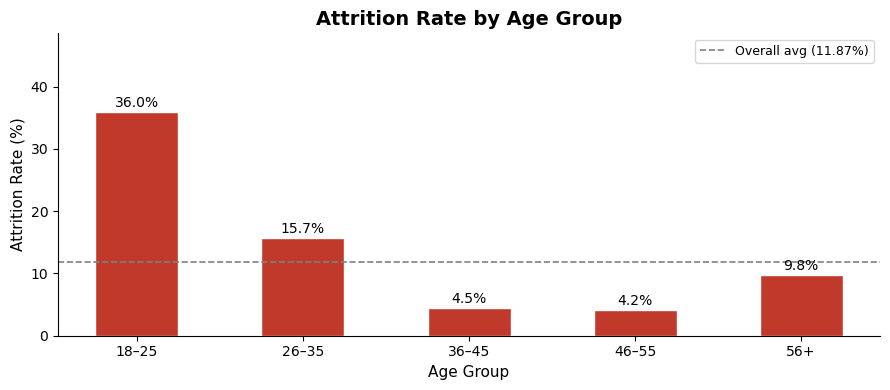

In [78]:
# Q3 — What are the age demographics of employees who left vs. stayed?

# Age bands
bins   = [17, 25, 35, 45, 55, 60]
labels = ['18–25', '26–35', '36–45', '46–55', '56+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Summary stats
print("Mean age — Left: {:.1f}  |  Stayed: {:.1f}\n".format(
    df[df['Attrition'] == 'Yes']['Age'].mean(),
    df[df['Attrition'] == 'No']['Age'].mean()
))

# Table
age_table = (
    df.groupby('AgeGroup', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
age_table['Attrition Rate'] = age_table['Attrition Rate'].map('{:.1f}%'.format)
print(age_table.to_string(index=False))

# Plot
age_rates = (
    df.groupby('AgeGroup', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    age_rates['AgeGroup'].astype(str),
    age_rates['Attrition Rate (%)'],
    color=PALETTE['Yes'],
    width=0.5,
    edgecolor='white'
)
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for bar, val in zip(bars, age_rates['Attrition Rate (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, age_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Finding:** Employees who left were on average 7 years younger than those who stayed (31 vs 38). The 18-25 group shows the severest attrition at 36% left. Highlighting that early-career employees are the most at-risk demographics of leaving. 



AgeGroup  Departures  % of Total Departures
   18–25          50                   25.1
   26–35         109                   54.8
   36–45          24                   12.1
   46–55          11                    5.5
     56+           5                    2.5


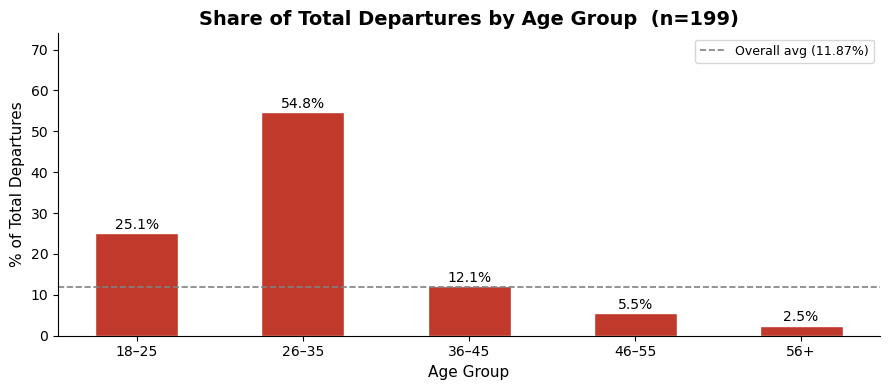

In [79]:
# Attrition by Age Group effect on Company
# Share of total departures by age group
total_left = (df['Attrition'] == 'Yes').sum()

departure_share = (
    df[df['Attrition'] == 'Yes']
    .groupby('AgeGroup', observed=True)
    .size()
    .reset_index(name='Departures')
)
departure_share['% of Total Departures'] = (
    departure_share['Departures'] / total_left * 100
).round(1)

print(departure_share.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    departure_share['AgeGroup'].astype(str),
    departure_share['% of Total Departures'],
    color=PALETTE['Yes'],
    width=0.5,
    edgecolor='white'
)
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for bar, val in zip(bars, departure_share['% of Total Departures']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_title('Share of Total Departures by Age Group  (n=199)')
ax.set_xlabel('Age Group')
ax.set_ylabel('% of Total Departures')
ax.set_ylim(0, departure_share['% of Total Departures'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:**  Employees under 35 drive the largest share of actual departures accounting for 80% of the companies total attrition. Nearly 4 out of every 5 people who left were under 35. Retention investment that doesn't target this segment won't move that number.

GENDER
Gender  Total  Left  Stayed Attrition Rate
Female  678.0  86.0   592.0          12.7%
  Male  998.0 113.0   885.0          11.3%

EDUCATION
EducationLabel  Total  Left  Stayed Attrition Rate
    No College  196.0  27.0   169.0          13.8%
  Some College  322.0  35.0   287.0          10.9%
      Bachelor  655.0  89.0   566.0          13.6%
        Master  447.0  47.0   400.0          10.5%
        Doctor   56.0   1.0    55.0           1.8%


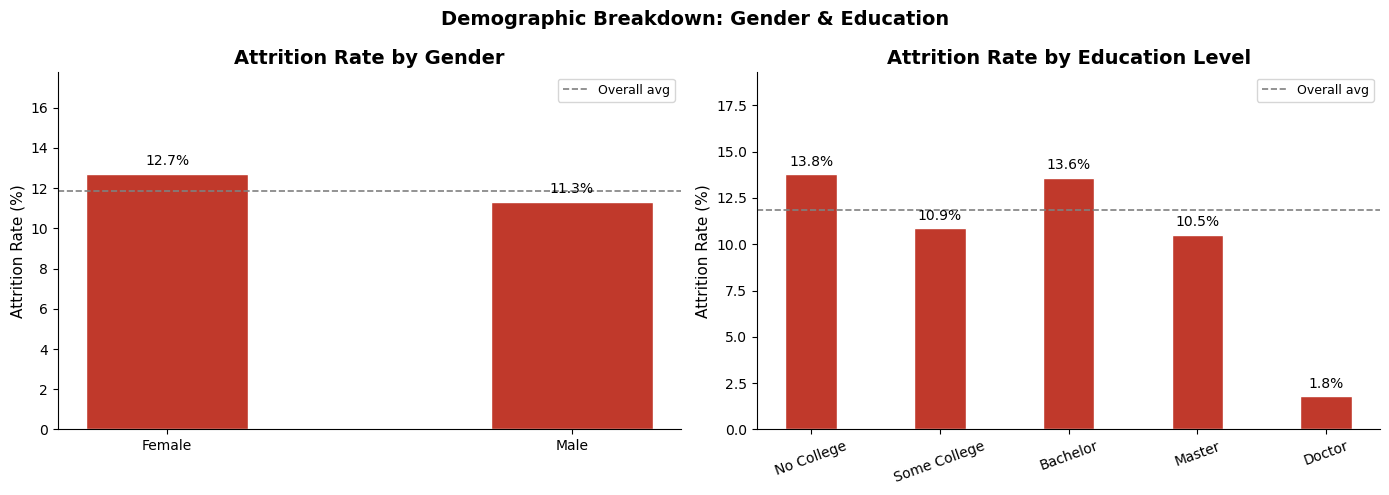

In [80]:
# Q4 — Is there a significant difference in attrition by gender or education level?

edu_labels = {1: 'No College', 2: 'Some College', 3: 'Bachelor', 4: 'Master', 5: 'Doctor'}
df['EducationLabel'] = df['Education'].map(edu_labels)
edu_order = ['No College', 'Some College', 'Bachelor', 'Master', 'Doctor']

# Gender table
gender_table = (
    df.groupby('Gender', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
gender_table['Attrition Rate'] = gender_table['Attrition Rate'].map('{:.1f}%'.format)
print("GENDER\n" + gender_table.to_string(index=False))

# Education table
edu_table = (
    df.groupby('EducationLabel', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
edu_table['EducationLabel'] = pd.Categorical(edu_table['EducationLabel'], categories=edu_order, ordered=True)
edu_table = edu_table.sort_values('EducationLabel')
edu_table['Attrition Rate'] = edu_table['Attrition Rate'].map('{:.1f}%'.format)
print("\nEDUCATION\n" + edu_table.to_string(index=False))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender
gender_rates = (
    df.groupby('Gender')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
axes[0].bar(gender_rates['Gender'], gender_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.4, edgecolor='white')
axes[0].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(gender_rates.iterrows()):
    axes[0].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[0].set_title('Attrition Rate by Gender')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, gender_rates['Attrition Rate (%)'].max() * 1.4)
axes[0].legend(fontsize=9)

# Education
edu_rates = (
    df.groupby('EducationLabel')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
edu_rates['EducationLabel'] = pd.Categorical(edu_rates['EducationLabel'], categories=edu_order, ordered=True)
edu_rates = edu_rates.sort_values('EducationLabel')
axes[1].bar(edu_rates['EducationLabel'], edu_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.4, edgecolor='white')
axes[1].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(edu_rates.iterrows()):
    axes[1].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition Rate by Education Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, edu_rates['Attrition Rate (%)'].max() * 1.4)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=9)

plt.suptitle('Demographic Breakdown: Gender & Education', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** Small gender gap by attrition rates. Within the Doctor Education level, one person left out 56, this suggests that highly specialized employees are essentially not leaving. Apart from Doctor, Education level attrition rates cluster around 10-14% with no pattern. Gender and Education dont really explain much so it tells us that the drivers are elsewhere -- likely compensation, workload, etc.

---

## Phase 2 — Job Role & Compensation

Tests whether structural factors — role type and pay level — predict who leaves.

**Business Questions:**
- How does job role impact the likelihood of attrition?
- Is there a noticeable difference in attrition rates among different salary levels?


       JobRole  Total  Left  Stayed Attrition Rate
         Other  534.0  87.0   447.0          16.3%
         Nurse  822.0 107.0   715.0          13.0%
     Therapist  189.0   4.0   185.0           2.1%
Administrative  115.0   1.0   114.0           0.9%
         Admin   16.0   0.0    16.0           0.0%


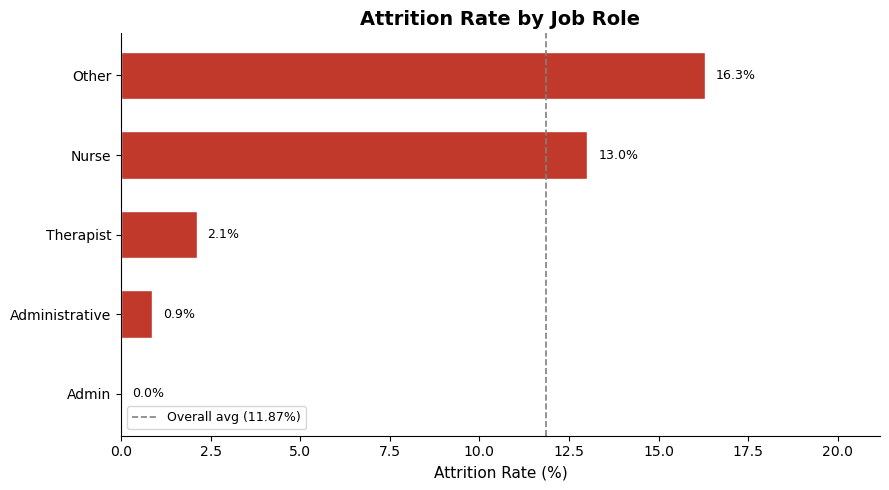

In [81]:
# Q5 — How does job role impact the likelihood of attrition?

# Table
role_table = (
    df.groupby('JobRole', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
    .sort_values('Attrition Rate', ascending=False)
)
role_table['Attrition Rate'] = role_table['Attrition Rate'].map('{:.1f}%'.format)
print(role_table.to_string(index=False))

# Plot — horizontal bars
role_rates = (
    df.groupby('JobRole')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
    .sort_values('Attrition Rate (%)', ascending=True)
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    role_rates['JobRole'],
    role_rates['Attrition Rate (%)'],
    color=PALETTE['Yes'],
    height=0.6,
    edgecolor='white'
)
ax.axvline(x=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for bar, val in zip(bars, role_rates['Attrition Rate (%)']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_title('Attrition Rate by Job Role')
ax.set_xlabel('Attrition Rate (%)')
ax.set_xlim(0, role_rates['Attrition Rate (%)'].max() * 1.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Nurses account for 107 of the 199 total departures - 53.8% of all attrition - despire a rate (13%) close to the company average. Thier sheer size (822 employees) makes them the single most important feoup for any retention program. The 'Other' cateogry shows the highest rate at 16%, but as a catch-all label it cannot be acted on without knowing which specific roles it contains - something worth investigating. Therapist and Admin staff leave at just 2.% and 1%, suggesting again that specialized roles are largely stable.

MONTHLY INCOME — LEAVERS VS STAYERS
           median    mean
Attrition                
No         5204.0  6852.0
Yes        2741.0  4024.0

SALARY QUARTILE BANDS
SalaryBand            Range  Total  Left Attrition Rate
  Q1 (Low)  $1,009 – $2,926    419   115          27.4%
        Q2  $2,929 – $4,898    419    35           8.4%
        Q3  $4,900 – $8,380    419    29           6.9%
 Q4 (High) $8,381 – $19,999    419    20           4.8%

JOB LEVEL  (1 = Entry → 5 = Senior)
 JobLevel  Total  Left Median Income Attrition Rate
        1    621   142        $2,691          22.9%
        2    606    34        $5,327           5.6%
        3    246    18        $9,988           7.3%
        4    122     3       $16,094           2.5%
        5     81     2       $19,197           2.5%


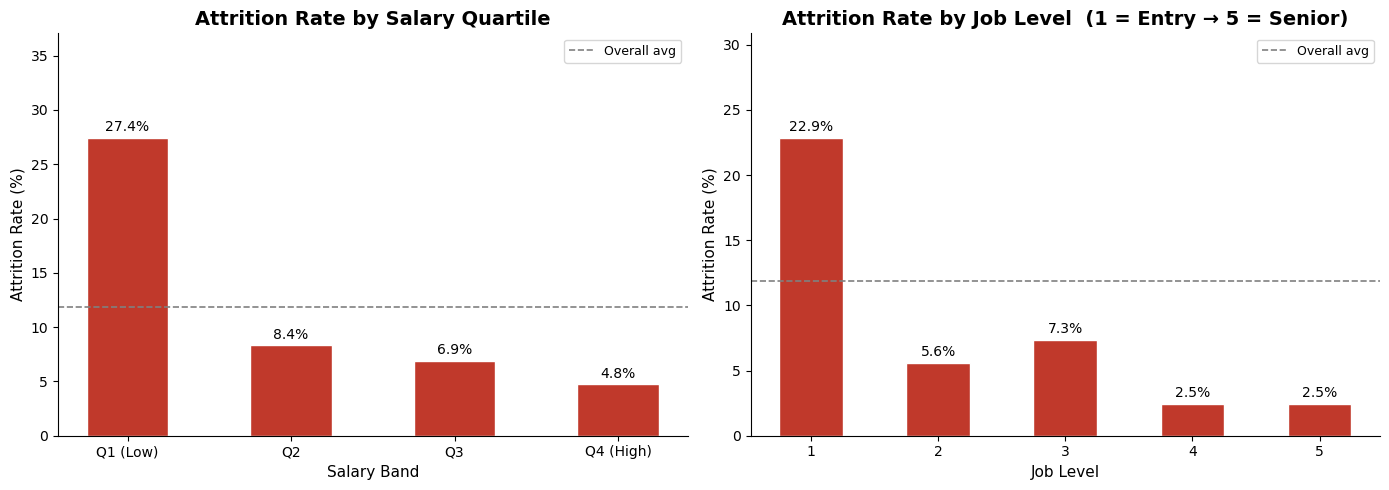

In [82]:
# Is there a noticeable difference in attrition rates among different salary levels?

# Income comparison: leavers vs stayers
print("MONTHLY INCOME — LEAVERS VS STAYERS")
print(df.groupby('Attrition')['MonthlyIncome'].agg(['median', 'mean']).round(0))
print()

# Salary quartile bands
df['SalaryBand'] = pd.qcut(df['MonthlyIncome'], q=4,
                            labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
salary_table = (
    df.groupby('SalaryBand', observed=True)
    .apply(lambda x: pd.Series({
        'Range':          f"${int(x['MonthlyIncome'].min()):,} – ${int(x['MonthlyIncome'].max()):,}",
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
salary_table['Attrition Rate'] = salary_table['Attrition Rate'].map('{:.1f}%'.format)
print("SALARY QUARTILE BANDS")
print(salary_table.to_string(index=False))
print()

# Job level table
level_table = (
    df.groupby('JobLevel', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Median Income':  f"${int(x['MonthlyIncome'].median()):,}",
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
level_table['Attrition Rate'] = level_table['Attrition Rate'].map('{:.1f}%'.format)
print("JOB LEVEL  (1 = Entry → 5 = Senior)")
print(level_table.to_string(index=False))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary quartile
salary_rates = (
    df.groupby('SalaryBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
axes[0].bar(salary_rates['SalaryBand'].astype(str),
            salary_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.5, edgecolor='white')
axes[0].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(salary_rates.iterrows()):
    axes[0].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[0].set_title('Attrition Rate by Salary Quartile')
axes[0].set_xlabel('Salary Band')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, salary_rates['Attrition Rate (%)'].max() * 1.35)
axes[0].legend(fontsize=9)

# Job level
level_rates = (
    df.groupby('JobLevel', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
axes[1].bar(level_rates['JobLevel'].astype(str),
            level_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.5, edgecolor='white')
axes[1].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(level_rates.iterrows()):
    axes[1].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition Rate by Job Level  (1 = Entry → 5 = Senior)')
axes[1].set_xlabel('Job Level')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, level_rates['Attrition Rate (%)'].max() * 1.35)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**Finding:** THe lowest paid quarter of employees (under $2,926/month) leave at 27% -- nearly 6 times the rate of the highest-paid quarter at 5%. The typical leaver earns $2,750, nearly half the $5,200 median of employees who stayed. Job level confirms the pattern that entry-level staff (Level 1) leave at 23% while senior employees (Level 4 & 5) both land at 2.5%. Compensation is one of the storngest predictors of attrition.

---

## Phase 3 — Satisfaction & Engagement

Tests whether how employees feel about their work predicts who leaves.

**Business Questions:**
- What is the relationship between job satisfaction and attrition?
- How does work-life balance correlate with attrition?
- Are there any trends between employee performance ratings and attrition?


  JobSatLabel  Total  Left  Stayed Attrition Rate
      1 - Low  329.0  52.0   277.0          15.8%
   2 - Medium  310.0  42.0   268.0          13.5%
     3 - High  507.0  60.0   447.0          11.8%
4 - Very High  530.0  45.0   485.0           8.5%


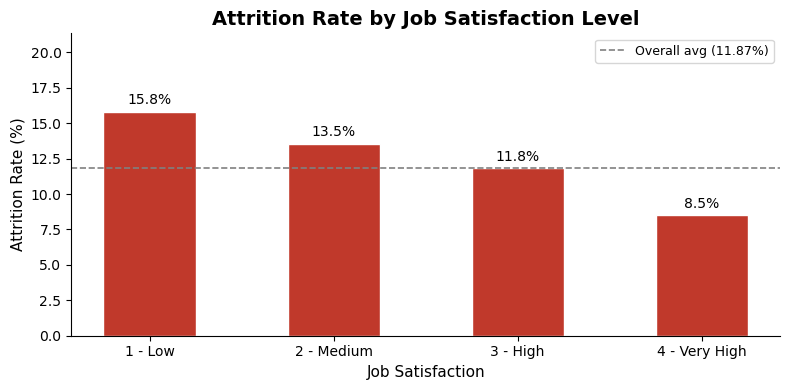

In [83]:
# What is the relationship between job satisfaction and attrition?

sat_labels = {1: '1 - Low', 2: '2 - Medium', 3: '3 - High', 4: '4 - Very High'}
df['JobSatLabel'] = df['JobSatisfaction'].map(sat_labels)
sat_order = list(sat_labels.values())

# Table
sat_table = (
    df.groupby('JobSatLabel', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
sat_table['JobSatLabel'] = pd.Categorical(sat_table['JobSatLabel'], categories=sat_order, ordered=True)
sat_table = sat_table.sort_values('JobSatLabel')
sat_table['Attrition Rate'] = sat_table['Attrition Rate'].map('{:.1f}%'.format)
print(sat_table.to_string(index=False))

# Plot
sat_rates = (
    df.groupby('JobSatLabel', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
sat_rates['JobSatLabel'] = pd.Categorical(sat_rates['JobSatLabel'], categories=sat_order, ordered=True)
sat_rates = sat_rates.sort_values('JobSatLabel')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sat_rates['JobSatLabel'].astype(str), sat_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(sat_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Job Satisfaction Level')
ax.set_xlabel('Job Satisfaction')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, sat_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Employees who are very satistified leave at nearly half the rate of thise with low satisfaction (9% vs 16%). Attrition falls consistently as job satisfaction rises.

       WLBLabel  Total  Left  Stayed Attrition Rate
    1 - Drained   90.0  24.0    66.0          26.7%
 2 - Imbalanced  385.0  54.0   331.0          14.0%
3 - Sustainable 1028.0 100.0   928.0           9.7%
 4 - Harmonious  173.0  21.0   152.0          12.1%


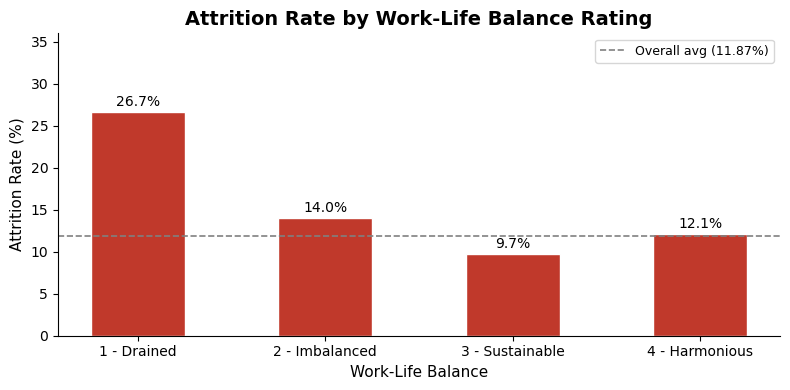

In [84]:
# How does work-life balance correlate with attrition?

wlb_labels = {1: '1 - Drained', 2: '2 - Imbalanced', 3: '3 - Sustainable', 4: '4 - Harmonious'}
df['WLBLabel'] = df['WorkLifeBalance'].map(wlb_labels)
wlb_order = list(wlb_labels.values())

# Table
wlb_table = (
    df.groupby('WLBLabel', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
wlb_table['WLBLabel'] = pd.Categorical(wlb_table['WLBLabel'], categories=wlb_order, ordered=True)
wlb_table = wlb_table.sort_values('WLBLabel')
wlb_table['Attrition Rate'] = wlb_table['Attrition Rate'].map('{:.1f}%'.format)
print(wlb_table.to_string(index=False))

# Plot
wlb_rates = (
    df.groupby('WLBLabel', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
wlb_rates['WLBLabel'] = pd.Categorical(wlb_rates['WLBLabel'], categories=wlb_order, ordered=True)
wlb_rates = wlb_rates.sort_values('WLBLabel')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(wlb_rates['WLBLabel'].astype(str), wlb_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(wlb_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Work-Life Balance Rating')
ax.set_xlabel('Work-Life Balance')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, wlb_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Employees who consider having a drained work-life balance are at major risk of leaving with 27%. However, the relationship isn't exactly linear as harmonious worklife employees have a sligthly higher risk (12%) than those rating it sustainable (10%), likely due to a smaller sample size of 173 vs 1028

Performance rating values present:
PerformanceRating
3    1424
4     252
Name: count, dtype: int64

      PerfLabel  Total  Left  Stayed Attrition Rate
  3 - Excellent 1424.0 167.0  1257.0          11.7%
4 - Outstanding  252.0  32.0   220.0          12.7%


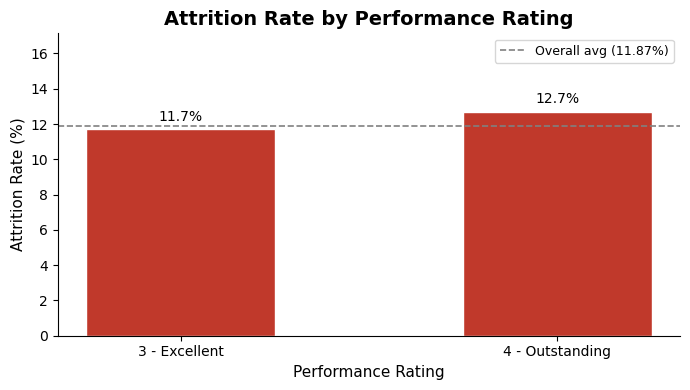

In [85]:
# Are there any trends between employee performance ratings and attrition?

perf_labels = {1: '1 - Low', 2: '2 - Good', 3: '3 - Excellent', 4: '4 - Outstanding'}
df['PerfLabel'] = df['PerformanceRating'].map(perf_labels)

# Check which values actually exist in the data
print("Performance rating values present:")
print(df['PerformanceRating'].value_counts().sort_index())
print()

perf_order = [v for k, v in perf_labels.items() if k in df['PerformanceRating'].unique()]

# Table
perf_table = (
    df.groupby('PerfLabel', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
perf_table['Attrition Rate'] = perf_table['Attrition Rate'].map('{:.1f}%'.format)
print(perf_table.to_string(index=False))

# Plot
perf_rates = (
    df.groupby('PerfLabel', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(perf_rates['PerfLabel'].astype(str), perf_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(perf_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Performance Rating')
ax.set_xlabel('Performance Rating')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, perf_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Minor gap between Attritate within Performance rating not a major driver.

---

## Phase 4 — Workload & Conditions

Tests whether how work amount and distance to work impact who leaves.

**Business Questions:**
- How does the distance from work impact employee attrition rate?
- Is there a correlation between training hours and attrition?



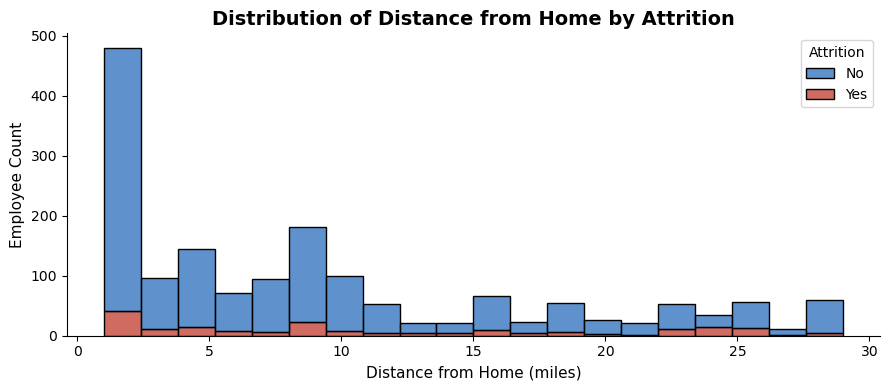

Distance stats — Left:   mean=11.6  median=9.0
Distance stats — Stayed: mean=8.9  median=7.0

    DistanceBand  Total  Left  Stayed Attrition Rate
      Near (1–5)  721.0  67.0   654.0           9.3%
 Moderate (6–10)  448.0  46.0   402.0          10.3%
     Far (11–20)  269.0  39.0   230.0          14.5%
Very Far (21–29)  238.0  47.0   191.0          19.7%


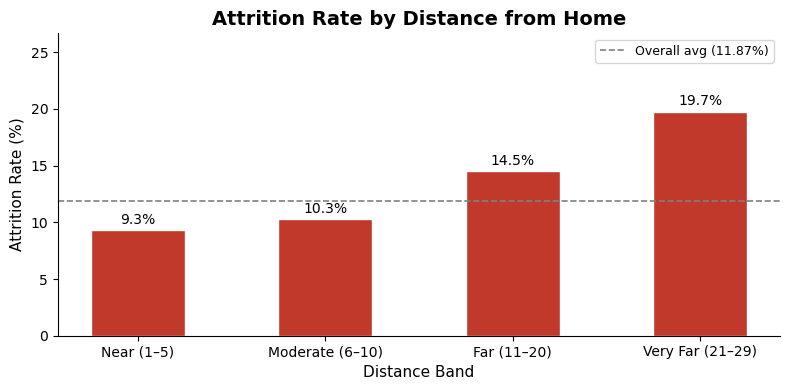

In [86]:
# Does distance from home affect employee attrition rates?

# --- Distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='DistanceFromHome', hue='Attrition',
             palette=PALETTE, multiple='stack', bins=20, ax=ax)
ax.set_title('Distribution of Distance from Home by Attrition')
ax.set_xlabel('Distance from Home (miles)')
ax.set_ylabel('Employee Count')
plt.tight_layout()
plt.show()

print(f"Distance stats — Left:   mean={df[df['Attrition']=='Yes']['DistanceFromHome'].mean():.1f}  median={df[df['Attrition']=='Yes']['DistanceFromHome'].median():.1f}")
print(f"Distance stats — Stayed: mean={df[df['Attrition']=='No']['DistanceFromHome'].mean():.1f}  median={df[df['Attrition']=='No']['DistanceFromHome'].median():.1f}")
print()

# --- Bin into distance bands ---
df['DistanceBand'] = pd.cut(df['DistanceFromHome'],
                             bins=[0, 5, 10, 20, 29],
                             labels=['Near (1–5)', 'Moderate (6–10)',
                                     'Far (11–20)', 'Very Far (21–29)'])

# Table
dist_table = (
    df.groupby('DistanceBand', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
dist_table['Attrition Rate'] = dist_table['Attrition Rate'].map('{:.1f}%'.format)
print(dist_table.to_string(index=False))

# Attrition rate chart
dist_rates = (
    df.groupby('DistanceBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(dist_rates['DistanceBand'].astype(str), dist_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(dist_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Distance from Home')
ax.set_xlabel('Distance Band')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, dist_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Very far employees leave at more than double the rate of near employees (9% vs 20%). In healthcare were shifts are early and very late, a long commute isn't convinient -- compounding affect of exhaustion and impacts work-life balance.

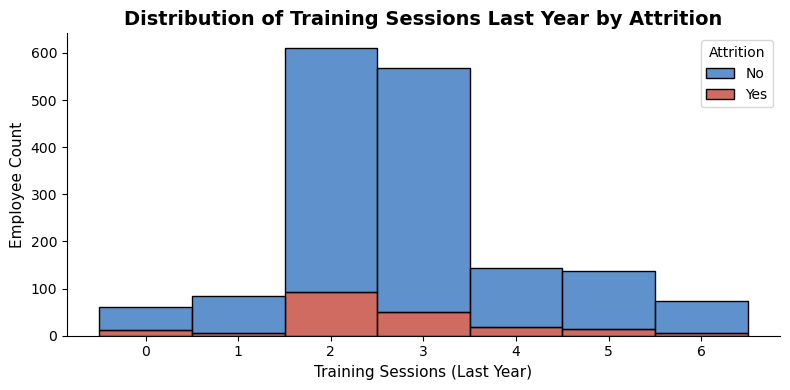

Training stats — Left:   mean=2.61
Training stats — Stayed: mean=2.83

 TrainingTimesLastYear  Total  Left  Stayed Attrition Rate
                     0   61.0  13.0    48.0          21.3%
                     1   84.0   5.0    79.0           6.0%
                     2  611.0  92.0   519.0          15.1%
                     3  567.0  51.0   516.0           9.0%
                     4  143.0  18.0   125.0          12.6%
                     5  137.0  14.0   123.0          10.2%
                     6   73.0   6.0    67.0           8.2%


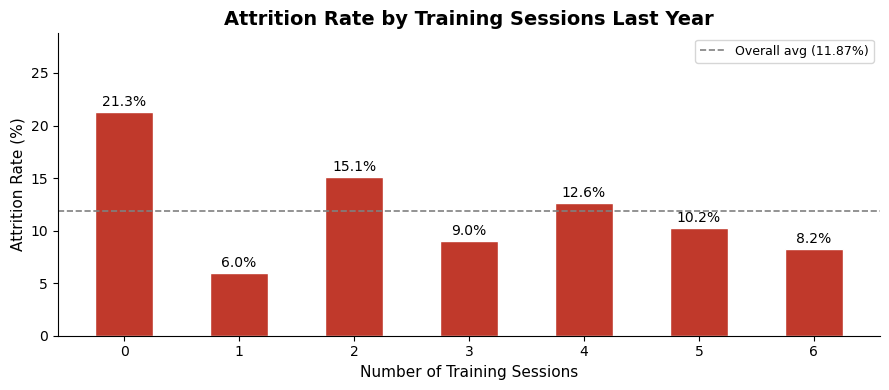

In [87]:
# Is there a correlation between number of training sessions and attrition?

# --- Distribution ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='TrainingTimesLastYear', hue='Attrition',
             palette=PALETTE, multiple='stack', discrete=True, ax=ax)
ax.set_title('Distribution of Training Sessions Last Year by Attrition')
ax.set_xlabel('Training Sessions (Last Year)')
ax.set_ylabel('Employee Count')
plt.tight_layout()
plt.show()

print(f"Training stats — Left:   mean={df[df['Attrition']=='Yes']['TrainingTimesLastYear'].mean():.2f}")
print(f"Training stats — Stayed: mean={df[df['Attrition']=='No']['TrainingTimesLastYear'].mean():.2f}")
print()

# Table — training is already discrete (0–6), no binning needed
train_table = (
    df.groupby('TrainingTimesLastYear', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
train_table['Attrition Rate'] = train_table['Attrition Rate'].map('{:.1f}%'.format)
print(train_table.to_string(index=False))

# Attrition rate chart
train_rates = (
    df.groupby('TrainingTimesLastYear', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(train_rates['TrainingTimesLastYear'].astype(str), train_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(train_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Training Sessions Last Year')
ax.set_xlabel('Number of Training Sessions')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, train_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** Employees who received no training leave at the highest rate (21%), indicating that absence of development investment is a retention risk. Beyond that the relationship isn't linear.

OverTime  Total  Left  Stayed Attrition Rate
      No 1200.0  60.0  1140.0           5.0%
     Yes  476.0 139.0   337.0          29.2%


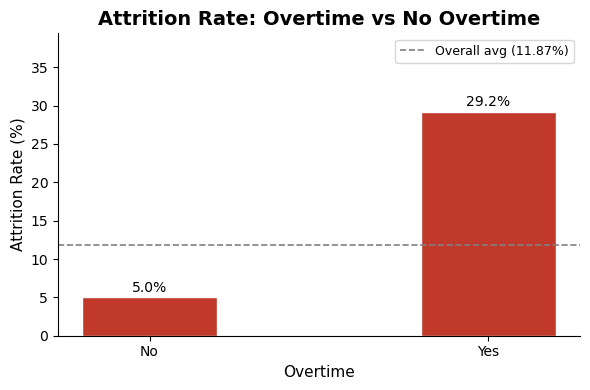

In [88]:
# Bonus — Does working overtime predict attrition?

# Table
ot_table = (
    df.groupby('OverTime', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
ot_table['Attrition Rate'] = ot_table['Attrition Rate'].map('{:.1f}%'.format)
print(ot_table.to_string(index=False))

# Chart
ot_rates = (
    df.groupby('OverTime')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ot_rates['OverTime'], ot_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.4, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(ot_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate: Overtime vs No Overtime')
ax.set_xlabel('Overtime')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, ot_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Fining:** 139 of 199 total departures (70%) came from overtime workers - yet overtime workers are only 28% of the workforce. 
70% of the attrition problem sits in 28% of the workforce. 

---

## Phase 5 — Career Progression

Tests how career progression visibility influences attrition levels

**Business Questions:**
- Years at the company vs attrition
- Promotions & years in current role vs attrition
- Career development opportunities vs retention


/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_44224/3364816110.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Attrition')


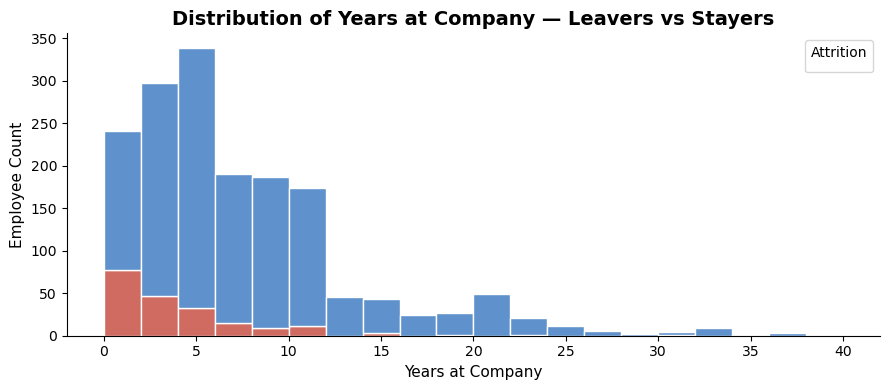

TenureBand  Total  Left  Stayed Attrition Rate
   0–2 yrs  387.0 107.0   280.0          27.6%
   3–5 yrs  491.0  50.0   441.0          10.2%
  6–10 yrs  514.0  35.0   479.0           6.8%
 11–20 yrs  208.0   5.0   203.0           2.4%
   21+ yrs   76.0   2.0    74.0           2.6%


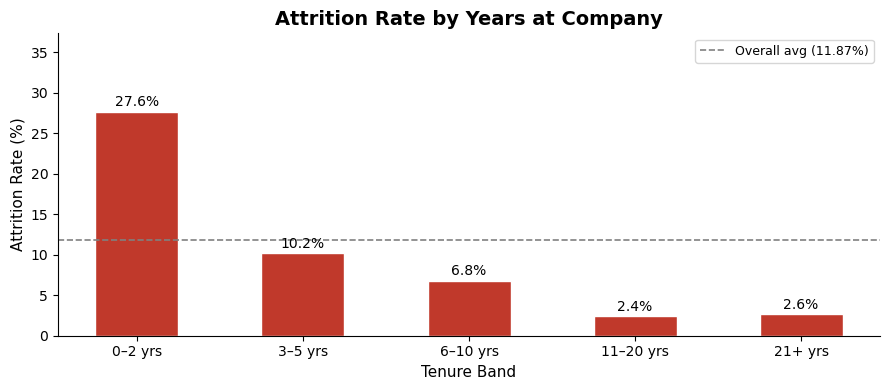

In [89]:
# Does tenure at the company predict attrition?

# Distribution
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', palette=PALETTE,
             multiple='stack', bins=20, edgecolor='white', ax=ax)
ax.set_title('Distribution of Years at Company — Leavers vs Stayers')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Employee Count')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

# Tenure bands
bins   = [0, 2, 5, 10, 20, 40]
labels = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11–20 yrs', '21+ yrs']
df['TenureBand'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels, include_lowest=True)

tenure_table = (
    df.groupby('TenureBand', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
tenure_table['Attrition Rate'] = tenure_table['Attrition Rate'].map('{:.1f}%'.format)
print(tenure_table.to_string(index=False))

# Plot
tenure_rates = (
    df.groupby('TenureBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(tenure_rates['TenureBand'].astype(str), tenure_rates['Attrition Rate (%)'],
              color=PALETTE['Yes'], width=0.5, edgecolor='white')
ax.axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(tenure_rates.iterrows()):
    ax.text(i, row['Attrition Rate (%)'] + 0.3,
            f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
ax.set_title('Attrition Rate by Years at Company')
ax.set_xlabel('Tenure Band')
ax.set_ylabel('Attrition Rate (%)')
ax.set_ylim(0, tenure_rates['Attrition Rate (%)'].max() * 1.35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Finding:** New hires clearly show higher attrition rates and are the most at risk with attrition levels dropping across Tenure at the company.

/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_44224/1752330301.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Attrition')


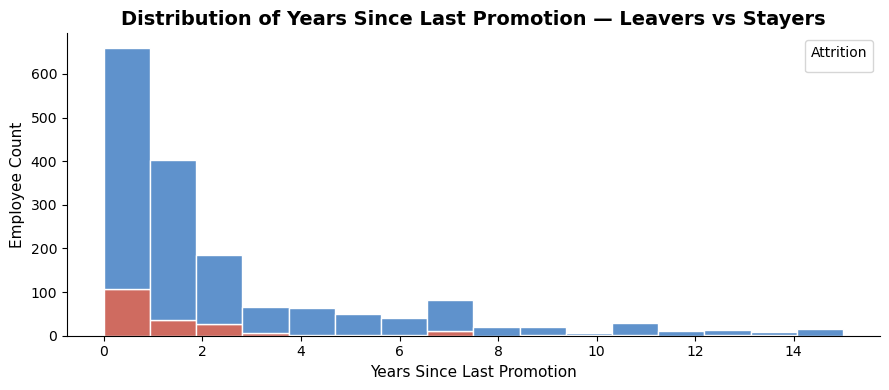

YEARS SINCE LAST PROMOTION
PromoBand  Total  Left  Stayed Attrition Rate
   0–1 yr 1062.0 143.0   919.0          13.5%
  2–4 yrs  315.0  35.0   280.0          11.1%
  5–8 yrs  195.0  14.0   181.0           7.2%
   9+ yrs  104.0   7.0    97.0           6.7%



/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_44224/1752330301.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Attrition')


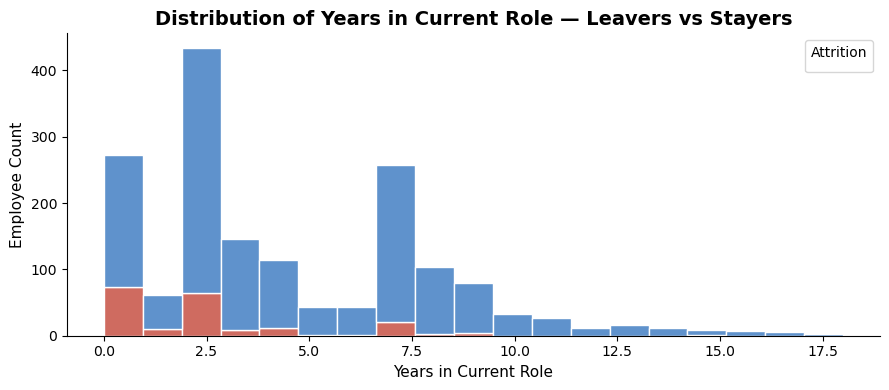

YEARS IN CURRENT ROLE
RoleBand  Total  Left  Stayed Attrition Rate
 0–2 yrs  768.0 148.0   620.0          19.3%
 3–5 yrs  303.0  22.0   281.0           7.3%
6–10 yrs  516.0  28.0   488.0           5.4%
 11+ yrs   89.0   1.0    88.0           1.1%


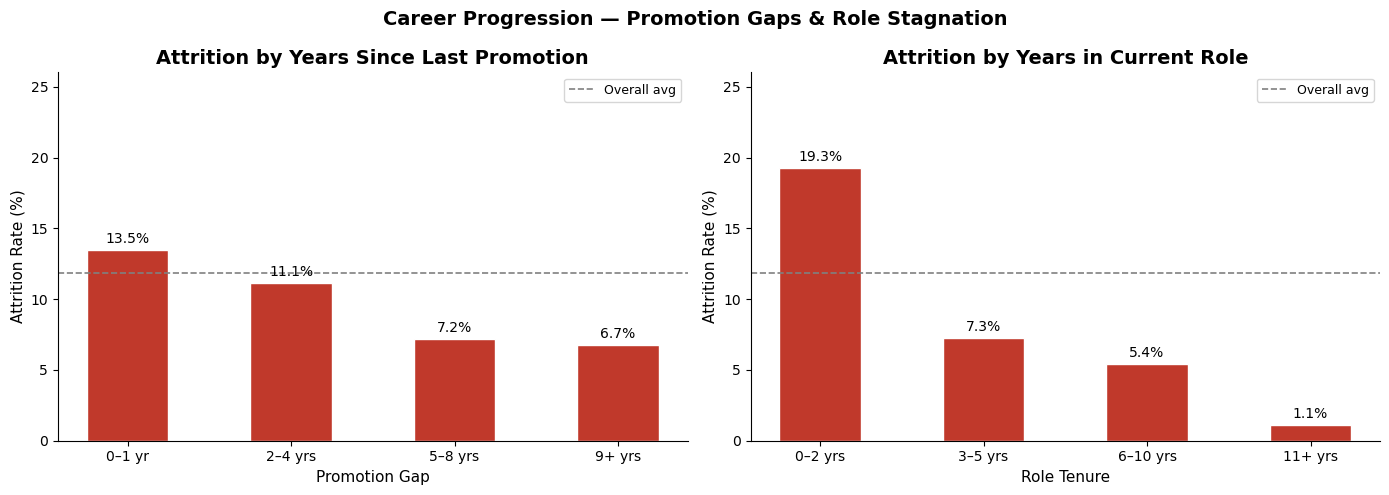

In [90]:
# Do promotion gaps and time stuck in a role predict attrition?

# ── Part A: Years Since Last Promotion — Distribution ──
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='YearsSinceLastPromotion', hue='Attrition', palette=PALETTE,
             multiple='stack', bins=16, edgecolor='white', ax=ax)
ax.set_title('Distribution of Years Since Last Promotion — Leavers vs Stayers')
ax.set_xlabel('Years Since Last Promotion')
ax.set_ylabel('Employee Count')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

# Promotion bands
bins_p   = [0, 1, 4, 8, 15]
labels_p = ['0–1 yr', '2–4 yrs', '5–8 yrs', '9+ yrs']
df['PromoBand'] = pd.cut(df['YearsSinceLastPromotion'], bins=bins_p, labels=labels_p, include_lowest=True)

promo_table = (
    df.groupby('PromoBand', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
promo_table['Attrition Rate'] = promo_table['Attrition Rate'].map('{:.1f}%'.format)
print("YEARS SINCE LAST PROMOTION")
print(promo_table.to_string(index=False))
print()

# ── Part B: Years In Current Role — Distribution ──
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='YearsInCurrentRole', hue='Attrition', palette=PALETTE,
             multiple='stack', bins=19, edgecolor='white', ax=ax)
ax.set_title('Distribution of Years in Current Role — Leavers vs Stayers')
ax.set_xlabel('Years in Current Role')
ax.set_ylabel('Employee Count')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

# Role tenure bands
bins_r   = [0, 2, 5, 10, 18]
labels_r = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11+ yrs']
df['RoleBand'] = pd.cut(df['YearsInCurrentRole'], bins=bins_r, labels=labels_r, include_lowest=True)

role_table = (
    df.groupby('RoleBand', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
role_table['Attrition Rate'] = role_table['Attrition Rate'].map('{:.1f}%'.format)
print("YEARS IN CURRENT ROLE")
print(role_table.to_string(index=False))

# ── Side-by-side attrition rate charts ──
promo_rates = (
    df.groupby('PromoBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
role_rates = (
    df.groupby('RoleBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)

y_max = max(promo_rates['Attrition Rate (%)'].max(), role_rates['Attrition Rate (%)'].max()) * 1.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(promo_rates['PromoBand'].astype(str), promo_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.5, edgecolor='white')
axes[0].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(promo_rates.iterrows()):
    axes[0].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[0].set_title('Attrition by Years Since Last Promotion')
axes[0].set_xlabel('Promotion Gap')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, y_max)
axes[0].legend(fontsize=9)

axes[1].bar(role_rates['RoleBand'].astype(str), role_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.5, edgecolor='white')
axes[1].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(role_rates.iterrows()):
    axes[1].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition by Years in Current Role')
axes[1].set_xlabel('Role Tenure')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, y_max)
axes[1].legend(fontsize=9)

plt.suptitle('Career Progression — Promotion Gaps & Role Stagnation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Finding:** Employees in thier dirst 2 years of a role leaveat 19%. The promotion gap shows the opposite of what is expected, likely because new hires are accounted in the recently promoted band. 

NUM COMPANIES WORKED — Mean:  Leavers 2.8 | Stayers 2.6



/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_44224/2724243899.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Attrition')


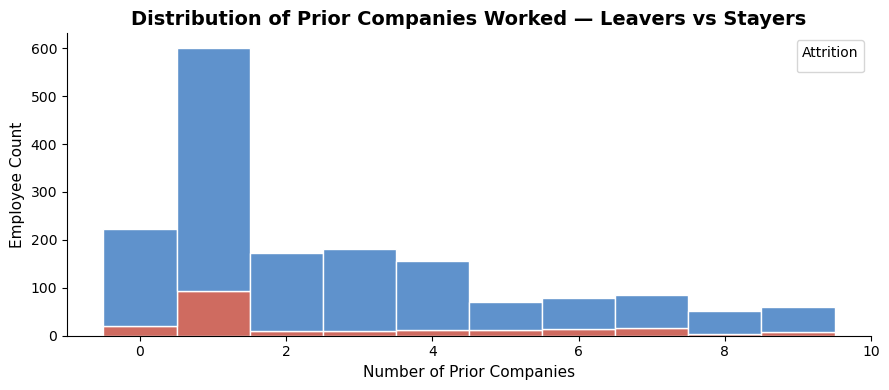

NUM COMPANIES WORKED
 NumCompaniesWorked  Total  Left Attrition Rate
                  0  223.0  20.0           9.0%
                  1  601.0  93.0          15.5%
                  2  173.0  10.0           5.8%
                  3  180.0  10.0           5.6%
                  4  156.0  11.0           7.1%
                  5   70.0  12.0          17.1%
                  6   79.0  15.0          19.0%
                  7   84.0  16.0          19.0%
                  8   51.0   4.0           7.8%
                  9   59.0   8.0          13.6%



/var/folders/pk/rjqjhmc53xj9pf16y09h48bc0000gn/T/ipykernel_44224/2724243899.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Attrition')


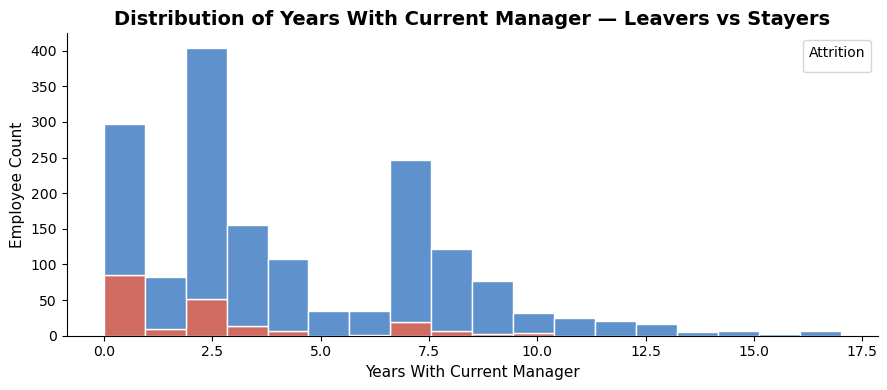

YEARS WITH CURRENT MANAGER
MgrBand  Total  Left  Stayed Attrition Rate
 0–1 yr  380.0  94.0   286.0          24.7%
2–4 yrs  667.0  72.0   595.0          10.8%
5–9 yrs  515.0  29.0   486.0           5.6%
10+ yrs  114.0   4.0   110.0           3.5%


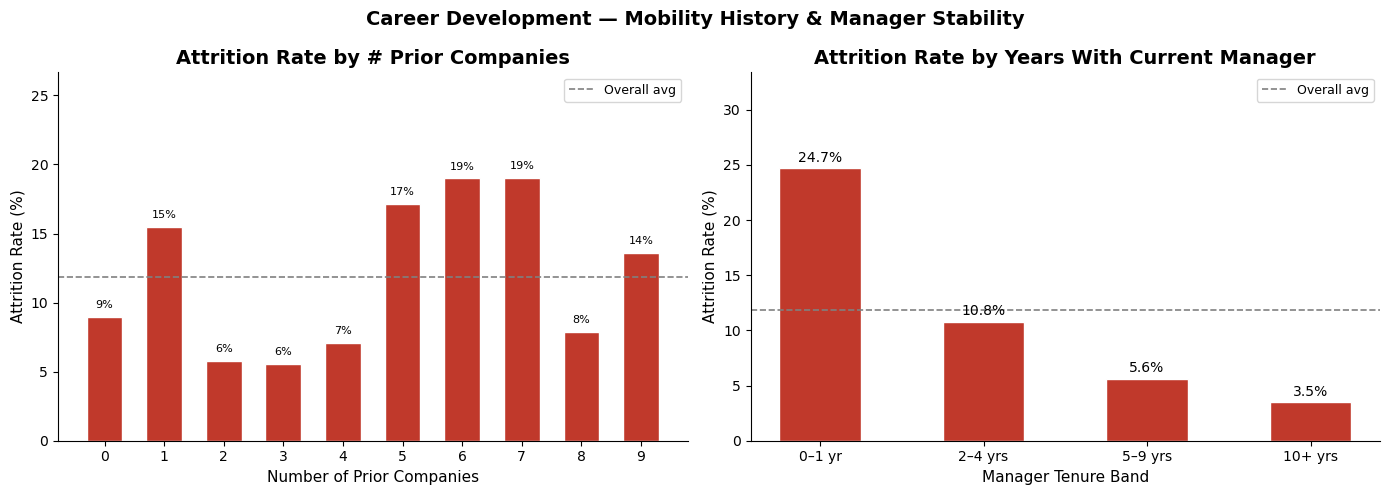

In [91]:
# Career development and mobility vs attrition
# Proxies: NumCompaniesWorked (mobility history), YearsWithCurrManager (manager stability)

# ── Part A: Number of Prior Companies — Distribution ──
print("NUM COMPANIES WORKED — Mean:  Leavers {:.1f} | Stayers {:.1f}\n".format(
    df[df['Attrition'] == 'Yes']['NumCompaniesWorked'].mean(),
    df[df['Attrition'] == 'No']['NumCompaniesWorked'].mean()
))

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='NumCompaniesWorked', hue='Attrition', palette=PALETTE,
             multiple='stack', discrete=True, edgecolor='white', ax=ax)
ax.set_title('Distribution of Prior Companies Worked — Leavers vs Stayers')
ax.set_xlabel('Number of Prior Companies')
ax.set_ylabel('Employee Count')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

# Table (discrete 0–9, no binning needed)
company_table = (
    df.groupby('NumCompaniesWorked')
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
company_table['Attrition Rate'] = company_table['Attrition Rate'].map('{:.1f}%'.format)
print("NUM COMPANIES WORKED")
print(company_table.to_string(index=False))
print()

# ── Part B: Years With Current Manager — Distribution ──
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x='YearsWithCurrManager', hue='Attrition', palette=PALETTE,
             multiple='stack', bins=18, edgecolor='white', ax=ax)
ax.set_title('Distribution of Years With Current Manager — Leavers vs Stayers')
ax.set_xlabel('Years With Current Manager')
ax.set_ylabel('Employee Count')
ax.legend(title='Attrition')
plt.tight_layout()
plt.show()

# Manager tenure bands
bins_m   = [0, 1, 4, 9, 17]
labels_m = ['0–1 yr', '2–4 yrs', '5–9 yrs', '10+ yrs']
df['MgrBand'] = pd.cut(df['YearsWithCurrManager'], bins=bins_m, labels=labels_m, include_lowest=True)

mgr_table = (
    df.groupby('MgrBand', observed=True)
    .apply(lambda x: pd.Series({
        'Total':          len(x),
        'Left':           int((x['Attrition'] == 'Yes').sum()),
        'Stayed':         int((x['Attrition'] == 'No').sum()),
        'Attrition Rate': round((x['Attrition'] == 'Yes').mean() * 100, 1)
    }), include_groups=False)
    .reset_index()
)
mgr_table['Attrition Rate'] = mgr_table['Attrition Rate'].map('{:.1f}%'.format)
print("YEARS WITH CURRENT MANAGER")
print(mgr_table.to_string(index=False))

# ── Side-by-side attrition rate charts ──
company_rates = (
    df.groupby('NumCompaniesWorked')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)
mgr_rates = (
    df.groupby('MgrBand', observed=True)['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
    .rename(columns={'Attrition': 'Attrition Rate (%)'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(company_rates['NumCompaniesWorked'].astype(str), company_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.6, edgecolor='white')
axes[0].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(company_rates.iterrows()):
    if row['Attrition Rate (%)'] > 0:
        axes[0].text(i, row['Attrition Rate (%)'] + 0.5,
                     f"{row['Attrition Rate (%)']:.0f}%", ha='center', va='bottom', fontsize=8)
axes[0].set_title('Attrition Rate by # Prior Companies')
axes[0].set_xlabel('Number of Prior Companies')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, company_rates['Attrition Rate (%)'].max() * 1.4)
axes[0].legend(fontsize=9)

axes[1].bar(mgr_rates['MgrBand'].astype(str), mgr_rates['Attrition Rate (%)'],
            color=PALETTE['Yes'], width=0.5, edgecolor='white')
axes[1].axhline(y=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg')
for i, (_, row) in enumerate(mgr_rates.iterrows()):
    axes[1].text(i, row['Attrition Rate (%)'] + 0.3,
                 f"{row['Attrition Rate (%)']:.1f}%", ha='center', va='bottom', fontsize=10)
axes[1].set_title('Attrition Rate by Years With Current Manager')
axes[1].set_xlabel('Manager Tenure Band')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_ylim(0, mgr_rates['Attrition Rate (%)'].max() * 1.35)
axes[1].legend(fontsize=9)

plt.suptitle('Career Development — Mobility History & Manager Stability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Finding:** Employees with 5-7 prior companies leave at 17-19% vs 5-7% for thise with 2-4. Job-hopper signal
Additionally, attrition rate is high with employees with 0-1 year with manager (25%). Suggests employees who haven't bonded with thier manager are at high-risk of leaving or recent manager changes disrupting stable employees is a driver. 

---

## Phase 6 — Synthesis

Putting all of it together

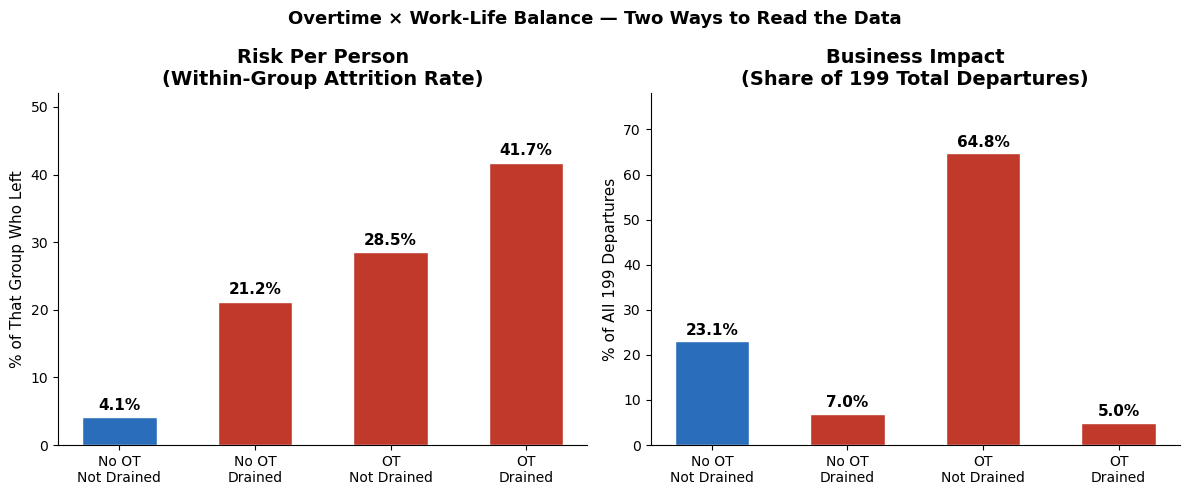

In [ ]:
#  Does overtime combined with poor work-life balance compound attrition risk?


seg_order   = ['No OT\nNot Drained', 'No OT\nDrained', 'OT\nNot Drained', 'OT\nDrained']
total_left  = (df['Attrition'] == 'Yes').sum()

seg_stats = (
    df.groupby('OT_WLB_Segment')
    .apply(lambda x: pd.Series({
        'rate':  round((x['Attrition'] == 'Yes').mean() * 100, 1),
        'share': round((x['Attrition'] == 'Yes').sum() / total_left * 100, 1)
    }), include_groups=False)
    .reset_index()
)
seg_stats['OT_WLB_Segment'] = pd.Categorical(seg_stats['OT_WLB_Segment'], categories=seg_order, ordered=True)
seg_stats = seg_stats.sort_values('OT_WLB_Segment')

bar_colors = [PALETTE['No'], PALETTE['Yes'], PALETTE['Yes'], PALETTE['Yes']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: within-group rate
axes[0].bar(seg_stats['OT_WLB_Segment'].astype(str), seg_stats['rate'],
            color=bar_colors, width=0.55, edgecolor='white')
for i, v in enumerate(seg_stats['rate']):
    axes[0].text(i, v + 0.7, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Risk Per Person\n(Within-Group Attrition Rate)')
axes[0].set_ylabel('% of That Group Who Left')
axes[0].set_ylim(0, 52)

# Right: share of total departures
axes[1].bar(seg_stats['OT_WLB_Segment'].astype(str), seg_stats['share'],
            color=bar_colors, width=0.55, edgecolor='white')
for i, v in enumerate(seg_stats['share']):
    axes[1].text(i, v + 0.7, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Business Impact\n(Share of 199 Total Departures)')
axes[1].set_ylabel('% of All 199 Departures')
axes[1].set_ylim(0, 78)

plt.suptitle('Overtime × Work-Life Balance — Two Ways to Read the Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


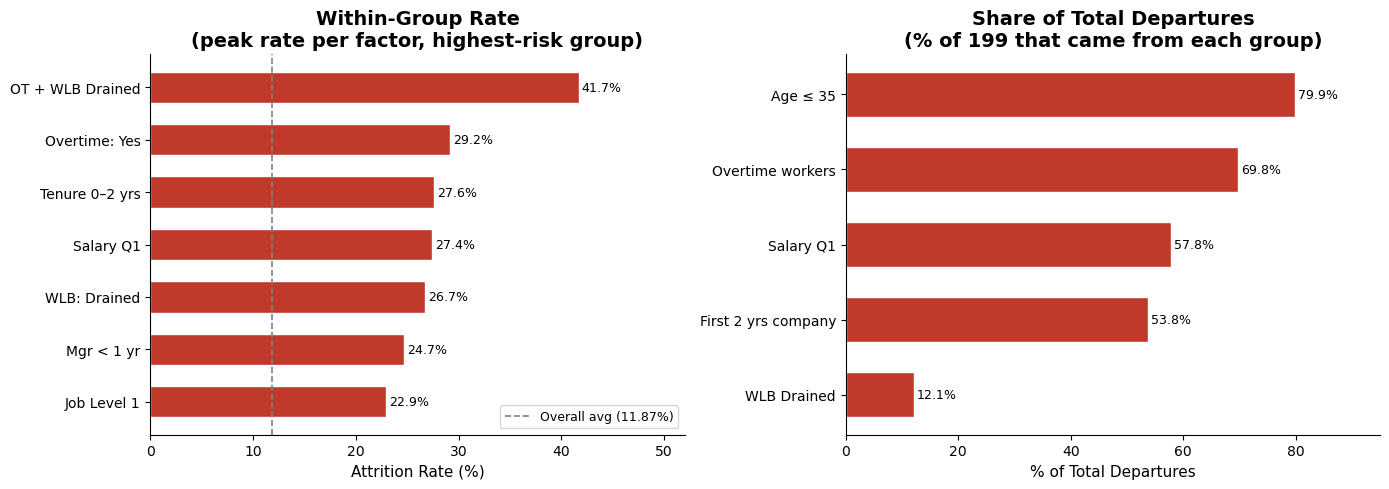

In [ ]:
#  Summary of all key drivers, ranked by peak attrition rate



total_left = (df['Attrition'] == 'Yes').sum()

# ── Chart A: ranked within-group peak rates (7 key factors) ──
summary = pd.DataFrame({
    'Factor': [
        'OT + WLB Drained',
        'Overtime: Yes',
        'Tenure 0–2 yrs',
        'Salary Q1',
        'WLB: Drained',
        'Mgr < 1 yr',
        'Job Level 1',
    ],
    'Rate': [41.7, 29.2, 27.6, 27.4, 26.7, 24.7, 22.9]
}).sort_values('Rate', ascending=True)

# ── Chart B: share of 199 departures by key group ──
q1_cutoff = df['MonthlyIncome'].quantile(0.25)
groups = {
    'WLB Drained':          (df['WorkLifeBalance'] == 1),
    'Salary Q1':            (df['MonthlyIncome'] <= q1_cutoff),
    'First 2 yrs company':  (df['YearsAtCompany'] <= 2),
    'Overtime workers':     (df['OverTime'] == 'Yes'),
    'Age ≤ 35':             (df['Age'] <= 35),
}
share_rows = []
for label, mask in groups.items():
    left = ((mask) & (df['Attrition'] == 'Yes')).sum()
    share_rows.append({'Group': label, 'Share': round(left / total_left * 100, 1)})
share_df = pd.DataFrame(share_rows).sort_values('Share', ascending=True)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart A
axes[0].barh(summary['Factor'], summary['Rate'],
             color=PALETTE['Yes'], height=0.6, edgecolor='white')
axes[0].axvline(x=11.87, color='gray', linestyle='--', linewidth=1.2, label='Overall avg (11.87%)')
for i, (_, row) in enumerate(summary.iterrows()):
    axes[0].text(row['Rate'] + 0.3, i, f"{row['Rate']:.1f}%", va='center', fontsize=9)
axes[0].set_title('Within-Group Rate\n(peak rate per factor, highest-risk group)')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_xlim(0, 52)
axes[0].legend(fontsize=9)

# Chart B
axes[1].barh(share_df['Group'], share_df['Share'],
             color=PALETTE['Yes'], height=0.6, edgecolor='white')
for i, (_, row) in enumerate(share_df.iterrows()):
    axes[1].text(row['Share'] + 0.5, i, f"{row['Share']:.1f}%", va='center', fontsize=9)
axes[1].set_title('Share of Total Departures\n(% of 199 that came from each group)')
axes[1].set_xlabel('% of Total Departures')
axes[1].set_xlim(0, 95)

plt.tight_layout()
plt.show()



              Group  Departure Share  Workforce Share
           Age ≤ 35             79.9             49.7
   Overtime workers             69.8             28.4
          Salary Q1             57.8             25.0
First 2 yrs company             53.8             23.1
        WLB Drained             12.1              5.4


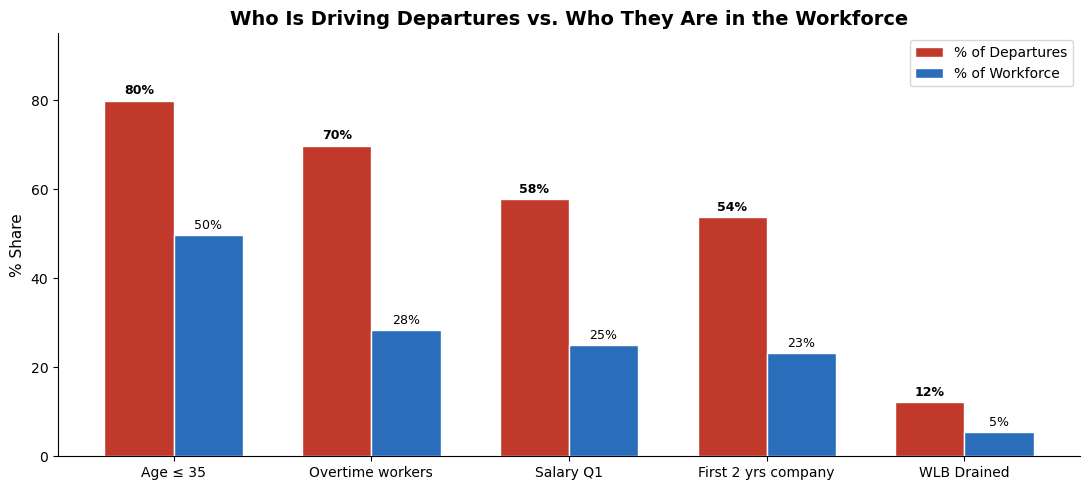

In [97]:
# Q16 — Chart B updated: departure share vs workforce share

total_left = (df['Attrition'] == 'Yes').sum()
total_n    = len(df)

q1_cutoff = df['MonthlyIncome'].quantile(0.25)
groups = {
    'Age ≤ 35':             (df['Age'] <= 35),
    'Overtime workers':     (df['OverTime'] == 'Yes'),
    'First 2 yrs company':  (df['YearsAtCompany'] <= 2),
    'Salary Q1':            (df['MonthlyIncome'] <= q1_cutoff),
    'WLB Drained':          (df['WorkLifeBalance'] == 1),
}

rows = []
for label, mask in groups.items():
    left      = ((mask) & (df['Attrition'] == 'Yes')).sum()
    workforce = mask.sum()
    rows.append({
        'Group':            label,
        'Departure Share':  round(left / total_left * 100, 1),
        'Workforce Share':  round(workforce / total_n * 100, 1),
    })

share_df = pd.DataFrame(rows).sort_values('Departure Share', ascending=False)
print(share_df.to_string(index=False))

# Grouped bar: departure share vs workforce share
x      = range(len(share_df))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar([i - width/2 for i in x], share_df['Departure Share'],
               width=width, color=PALETTE['Yes'], label='% of Departures', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], share_df['Workforce Share'],
               width=width, color=PALETTE['No'],  label='% of Workforce',  edgecolor='white')

for bar, val in zip(bars1, share_df['Departure Share']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, val in zip(bars2, share_df['Workforce Share']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(share_df['Group'])
ax.set_ylabel('% Share')
ax.set_ylim(0, 95)
ax.set_title('Who Is Driving Departures vs. Who They Are in the Workforce')
ax.legend()
plt.tight_layout()
plt.show()


## Summary & Recommendations

The 12% attrition average rate clusters around three distinct factors

**Overtime and burnout** is the strongest signal in the dataset. Overtime workers make up 28% of the workforce but account for 70% of all 199 departures — 2.5x their expected share. When overtime combines with poor work-life balance the rate hits 42%, the highest of any segment in the analysis. This is an organizational decision, not a demographic fact. It can be changed.

**Compensation** separates who leaves from who stays. Leavers earned a median of $2,700/month vs. $5,200 for stayers — a 90% gap. The bottom salary quartile leaves at 27%, six times the top quartile's 5%. Entry-level staff (Job Level 1) leave at 23%. Nurses make up 54% of all departures despite a near-average individual rate, because they are both the largest group and the most concentrated in lower pay bands and overtime shifts.

**The first two years** are the highest-risk window. Employees with under 2 years at the organization leave at 28%, more than double the company average. Once past 3 years attrition drops sharply and stays below average. Over half of all 199 departures had been at the organization 2 years or less.

---

**High-risk profile:** Under 35 · Nurse · First 2 years · Working overtime · Bottom salary quartile · Cardiology. Each factor individually elevates risk. Together they describe the employee this organization is most consistently losing.

---

**Three recommendations:**

1. **Overtime reform** — Cap mandatory overtime for Nurses and Cardiology staff. Flag employees working overtime while reporting poor work-life balance — that group leaves at 42%. This single lever touches 70% of the departure problem.

2. **New hire retention (0–24 months)** — Structured 90-day and 6-month check-ins, mentorship pairing, early role clarity. The data shows the first two years are when the organization consistently loses people.

3. **Entry-level pay audit** — The 90% income gap between leavers and stayers starts at the bottom. A systematic review of Job Level 1 and Salary Q1 compensation targets the most financially-exposed employees before they leave.


---
## Profile Deep-Dive — Are New Hires Being Put on Overtime?

The three main drivers (overtime, pay, tenure) may not be independent. If newer employees are more likely to be scheduled for overtime, the risks compound. These two charts test that.

In [ ]:
# Are new hires more likely to be on overtime?
ot_by_tenure = (
    df.groupby('TenureBand', observed=True)['OverTime']
    .apply(lambda x: round((x == 'Yes').mean() * 100, 1))
    .reset_index()
    .rename(columns={'OverTime': 'OT_Rate'})
)
print(ot_by_tenure.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#C0392B' if r > 30 else '#2A6EBB' for r in ot_by_tenure['OT_Rate']]
bars = ax.bar(ot_by_tenure['TenureBand'], ot_by_tenure['OT_Rate'],
              color=colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, ot_by_tenure['OT_Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
overall_ot = round((df['OverTime'] == 'Yes').mean() * 100, 1)
ax.axhline(overall_ot, color='#1C2B4A', linestyle='--', linewidth=1,
           label=f'Overall OT rate {overall_ot:.0f}%')
ax.set_title('Overtime Rate by Tenure Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Band')
ax.set_ylabel('% of employees on overtime')
ax.set_ylim(0, 55)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [ ]:
# Tenure × Overtime compound — two-lens view
df['Early'] = df['YearsAtCompany'] <= 2
seg_map = {
    (True,  'Yes'): '0–2 yrs\n+ OT',
    (True,  'No' ): '0–2 yrs\nNo OT',
    (False, 'Yes'): '3+ yrs\n+ OT',
    (False, 'No' ): '3+ yrs\nNo OT',
}
df['TenureOT'] = df.apply(lambda r: seg_map[(r['Early'], r['OverTime'])], axis=1)
seg_order  = ['0–2 yrs\n+ OT', '0–2 yrs\nNo OT', '3+ yrs\n+ OT', '3+ yrs\nNo OT']
total_left = (df['Attrition'] == 'Yes').sum()

seg_stats = (
    df.groupby('TenureOT')
    .apply(lambda x: pd.Series({
        'rate':  round((x['Attrition'] == 'Yes').mean() * 100, 1),
        'share': round((x['Attrition'] == 'Yes').sum() / total_left * 100, 1),
        'n':     len(x),
    }), include_groups=False)
    .reindex(seg_order)
    .reset_index()
)
print(seg_stats.to_string(index=False))

bar_colors = [PALETTE['Yes'], '#E67E22', '#5D6D7E', PALETTE['No']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Tenure × Overtime — Attrition Rate and Share of Departures',
             fontsize=14, fontweight='bold', y=1.01)

# Left — within-group attrition rate
ax = axes[0]
bars = ax.bar(seg_stats['TenureOT'], seg_stats['rate'],
              color=bar_colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, seg_stats['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(11.87, color='#1C2B4A', linestyle='--', linewidth=1, label='Company avg 12%')
ax.set_title('Within-Group Attrition Rate', fontsize=12)
ax.set_ylabel('Attrition rate (%)')
ax.set_ylim(0, 65)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Right — share of total departures
ax = axes[1]
bars = ax.bar(seg_stats['TenureOT'], seg_stats['share'],
              color=bar_colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, seg_stats['share']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Share of Total Departures', fontsize=12)
ax.set_ylabel('% of all 199 departures')
ax.set_ylim(0, 55)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


**Finding:** New hires (first two years) on overtime are the single highest-risk segment in the dataset. The left chart shows their attrition rate; the right shows how much of the departure volume they represent. This confirms the profile: it is not that young employees are simply leaving — they are being scheduled for overtime before they have any institutional reason to stay.